<a href="https://colab.research.google.com/github/DishaAndre/Star_Type_Prediction_System/blob/main/Star_Type_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Star Type Prediction System**

**Importing Required Libraries:**
In this step, all the necessary Python libraries are imported. These libraries are used for data handling, visualization, preprocessing, building different machine learning models, and evaluating their performance.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RANSACRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from scipy import stats
from sklearn.model_selection import cross_val_score, KFold

Load the dataset star_type_dataset.csv into a pandas DataFrame for analysis and model building.

In [ ]:
#Load the dataset
df = pd.read_csv('/content/sample_data/star_type_dataset.csv')
display(df)

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute Magnitude (Mv),Color,Spectral Class,Galaxy,Constellation,Age (in million years),Metallicity ([Fe/H]),Rotational Velocity (km/s),Distance (light years),Star Type ID,Star Type
0,3882,0.002749,0.116150,11.232131,Orange,K,Andromeda,Cygnus,2072.429337,-0.831932,9.914174,6279.918705,1,Red Dwarf
1,4866,0.234267,0.682442,6.405724,Orange,K,Milky Way,Ursa Major,8061.732185,0.399705,8.937917,399.135195,3,Main Sequence
2,8340,0.001363,0.017720,11.993847,White,A,Triangulum,Cassiopeia,611.833850,-0.436312,205.773440,2056.084304,2,White Dwarf
3,7176,3.828776,1.268587,3.372350,Yellow-White,F,Milky Way,Pegasus,1549.733369,-0.472496,90.250004,4889.970842,3,Main Sequence
4,6412,37938.044899,158.163228,-6.617687,Yellow-White,F,Milky Way,Lyra,185.828099,-0.220985,67.493993,57183.271180,4,Supergiant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,3011,0.003677,0.223288,10.916341,Red,NaN,Triangulum,Cassiopeia,2804.458113,-0.023119,9.804284,282.034438,1,Red Dwarf
14996,3150,0.030142,0.584141,8.632081,Red,M,Sombrero,Aquila,6438.892245,0.026648,2.492165,111.619790,1,Red Dwarf
14997,3356,0.002185,0.138551,11.481512,Red,M,Sombrero,Perseus,12355.680006,0.003335,6.334531,13.013081,1,Red Dwarf
14998,2432,0.000993,0.177900,12.337265,Red,M,Sombrero,Orion,5870.911522,0.500000,5.809762,1603.770339,1,Red Dwarf


### Dataset Overview

We first check the shape of the dataset to know the number of rows and columns.
Then we display the first and last rows, along with a few random samples to get an idea of the data.
Finally, we view a concise summary and descriptive statistics for the numerical columns.

In [ ]:
#Get the shape of the dataset
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(15000, 14)


In [ ]:
# View first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Temperature (K)  Luminosity (L/Lo)  Radius (R/Ro)  Absolute Magnitude (Mv)  \
0             3882           0.002749       0.116150                11.232131   
1             4866           0.234267       0.682442                 6.405724   
2             8340           0.001363       0.017720                11.993847   
3             7176           3.828776       1.268587                 3.372350   
4             6412       37938.044899     158.163228                -6.617687   

          Color Spectral Class      Galaxy Constellation  \
0        Orange              K   Andromeda        Cygnus   
1        Orange              K   Milky Way    Ursa Major   
2         White              A  Triangulum    Cassiopeia   
3  Yellow-White              F   Milky Way       Pegasus   
4  Yellow-White              F   Milky Way          Lyra   

   Age (in million years)  Metallicity ([Fe/H])  Rotational Velocity (km/s)  \
0             2072.429337             -0.831

In [ ]:
# View last 5 rows
print("Last 5 rows of the dataset")
print(df.tail())

Last 5 rows of the dataset
       Temperature (K)  Luminosity (L/Lo)  Radius (R/Ro)  \
14995             3011           0.003677       0.223288   
14996             3150           0.030142       0.584141   
14997             3356           0.002185       0.138551   
14998             2432           0.000993       0.177900   
14999             6087           0.000392       0.017850   

       Absolute Magnitude (Mv)         Color Spectral Class      Galaxy  \
14995                10.916341           Red            NaN  Triangulum   
14996                 8.632081           Red              M    Sombrero   
14997                11.481512           Red              M    Sombrero   
14998                12.337265           Red              M    Sombrero   
14999                13.345582  Yellow-White              F   Andromeda   

      Constellation  Age (in million years)  Metallicity ([Fe/H])  \
14995    Cassiopeia             2804.458113             -0.023119   
14996        Aquila    

In [ ]:
#View a random sample of rows
print("Random 5 rows from the dataset")
df.sample(5)

Random 5 rows from the dataset


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute Magnitude (Mv),Color,Spectral Class,Galaxy,Constellation,Age (in million years),Metallicity ([Fe/H]),Rotational Velocity (km/s),Distance (light years),Star Type ID,Star Type
7714,1457,0.000029,0.085131,16.162741,Red,M,Milky Way,Orion,1329.893427,-0.041765,7.444114,18407.551774,0,Brown Dwarf
14103,10035,130.643373,3.789344,-0.460218,Blue-White,B,Andromeda,Pegasus,5.737639,0.363497,245.763824,3881.783683,3,Main Sequence
1848,1662,0.000061,0.094505,15.364184,Red,M,Sombrero,Orion,3846.242731,-0.691383,3.306595,171.552735,0,Brown Dwarf
10426,4478,0.070951,0.443473,7.702598,Orange,K,Sombrero,Cassiopeia,9172.529233,-0.176052,6.489763,83.138792,1,Red Dwarf
12016,4006,0.084788,0.605760,7.509161,Orange,K,Whirlpool,Cassiopeia,10752.496293,0.359924,6.577053,69798.583123,3,Main Sequence


**Concise Summary of Data:**
In this step, we display a concise summary of the dataset to understand its structure. It shows the number of rows and columns, column names, data types, and non-null values in each column.


In [ ]:
#Concise summary of data
print("Concise summary of the dataset")
df.info()

Concise summary of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Temperature (K)             15000 non-null  int64  
 1   Luminosity (L/Lo)           15000 non-null  float64
 2   Radius (R/Ro)               15000 non-null  float64
 3   Absolute Magnitude (Mv)     15000 non-null  float64
 4   Color                       14700 non-null  object 
 5   Spectral Class              14700 non-null  object 
 6   Galaxy                      15000 non-null  object 
 7   Constellation               15000 non-null  object 
 8   Age (in million years)      14700 non-null  float64
 9   Metallicity ([Fe/H])        14700 non-null  float64
 10  Rotational Velocity (km/s)  14700 non-null  float64
 11  Distance (light years)      14700 non-null  float64
 12  Star Type ID                15000 non-null  int64  
 13  

**Descriptive Statistics for Numerical Columns:**
This step displays summary statistics for all numerical columns in the dataset. It includes values like mean, median, standard deviation, minimum, maximum, and quartiles, which help in understanding the data distribution and variability.


In [ ]:
#Descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns")
display(df.describe())

Descriptive statistics for numerical columns


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute Magnitude (Mv),Age (in million years),Metallicity ([Fe/H]),Rotational Velocity (km/s),Distance (light years),Star Type ID
count,15000.000000,1.500000e+04,15000.000000,15000.000000,14700.000000,14700.000000,14700.000000,14700.000000,15000.000000
mean,5738.729600,2.824617e+06,62.489976,6.216801,5616.860567,-0.019922,43.878333,10794.856089,2.128267
std,4654.715091,3.791049e+07,209.684482,7.177768,4143.699246,0.362477,70.050681,20441.432593,1.222585
min,800.000000,1.980002e-06,0.008004,-18.103157,1.012774,-1.599612,1.000347,10.001369,0.000000
25%,3214.000000,5.192790e-03,0.231031,4.442248,1704.508004,-0.267513,5.074961,102.729815,1.000000
50%,4552.000000,3.148912e-02,0.488588,8.584599,5386.787196,-0.001695,9.307556,1023.510597,2.000000
75%,6623.000000,1.429226e+00,1.174739,10.541498,9284.011392,0.266520,52.744261,9891.086965,3.000000
max,49776.000000,1.490263e+09,1997.561669,19.088336,12999.529827,0.500000,394.302176,99977.818831,5.000000


### Handling Missing and Duplicate Values

**Checking for Missing Values:**
In this step, we check if any columns in the dataset have missing values. The output shows the number of missing entries in each column. This helps identify which features need data cleaning or imputation before further analysis.


In [ ]:
# Check for missing values in each column
print("Missing values count in each column")
print(df.isnull().sum())

Missing values count in each column
Temperature (K)                 0
Luminosity (L/Lo)               0
Radius (R/Ro)                   0
Absolute Magnitude (Mv)         0
Color                         300
Spectral Class                300
Galaxy                          0
Constellation                   0
Age (in million years)        300
Metallicity ([Fe/H])          300
Rotational Velocity (km/s)    300
Distance (light years)        300
Star Type ID                    0
Star Type                       0
dtype: int64


**Handling Missing Values (Deletion Technique):**
In this step, all rows containing missing values are removed from the dataset using the deletion method. After applying this technique, the dataset no longer contains any missing entries, ensuring clean and complete data for further analysis.



In [ ]:
df_dropped = df.dropna()
print("Missing values count after handling by deletion technique:")
print(df_dropped.isnull().sum())

Missing values count after handling by deletion technique:
Temperature (K)               0
Luminosity (L/Lo)             0
Radius (R/Ro)                 0
Absolute Magnitude (Mv)       0
Color                         0
Spectral Class                0
Galaxy                        0
Constellation                 0
Age (in million years)        0
Metallicity ([Fe/H])          0
Rotational Velocity (km/s)    0
Distance (light years)        0
Star Type ID                  0
Star Type                     0
dtype: int64


**Handling Missing Values (KNN Imputation Technique):**
In this step, missing values are handled using the **K-Nearest Neighbors (KNN) Imputation** method.
Before applying KNN, categorical columns are encoded into numerical form. The imputer then fills missing values based on the nearest neighbors’ average values.
After applying this technique, all missing values are successfully replaced, and the dataset becomes complete without any null entries.


In [ ]:
from sklearn.impute import KNNImputer

knn_data = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Color', 'Spectral Class', 'Galaxy', 'Constellation', 'Star Type']:
    knn_data[col] = le.fit_transform(knn_data[col])

imputer = KNNImputer(n_neighbors=3)
knn_imputed = imputer.fit_transform(knn_data.select_dtypes(include=['float64', 'int64']))
knn_data[knn_data.select_dtypes(include=['float64', 'int64']).columns] = knn_imputed

print("Missing values count after handling by knn imputation technique:")
print(knn_data.isnull().sum())


Missing values count after handling by knn imputation technique:
Temperature (K)               0
Luminosity (L/Lo)             0
Radius (R/Ro)                 0
Absolute Magnitude (Mv)       0
Color                         0
Spectral Class                0
Galaxy                        0
Constellation                 0
Age (in million years)        0
Metallicity ([Fe/H])          0
Rotational Velocity (km/s)    0
Distance (light years)        0
Star Type ID                  0
Star Type                     0
dtype: int64


**Handling Missing Values (Median and Mode Imputation):**
In this step, missing values are replaced using **median** for numerical columns and **mode** for categorical columns.
The median helps to handle outliers effectively in numerical data, while the mode fills the most frequent category for categorical features.
After applying this method, all missing values in both numerical and categorical columns are successfully filled.


In [ ]:
# Identify missing values
numerical_cols_with_missing = ['Age (in million years)', 'Metallicity ([Fe/H])',
                               'Rotational Velocity (km/s)', 'Distance (light years)']
categorical_cols_with_missing = ['Color', 'Spectral Class']

In [ ]:
# Handle missing numerical values by filling with the median
for col in numerical_cols_with_missing:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"Filled missing values in '{col}' with median: {median_value:.4f}")

# Handle missing categorical values by filling with the mode
for col in categorical_cols_with_missing:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Filled missing values in '{col}' with mode: {mode_value}")

Filled missing values in 'Age (in million years)' with median: 5386.7872
Filled missing values in 'Metallicity ([Fe/H])' with median: -0.0017
Filled missing values in 'Rotational Velocity (km/s)' with median: 9.3076
Filled missing values in 'Distance (light years)' with median: 1023.5106
Filled missing values in 'Color' with mode: Red
Filled missing values in 'Spectral Class' with mode: M


In [ ]:
# Verify that all missing values have been handled
print("Missing values count after handling")
print(df.isnull().sum())

Missing values count after handling
Temperature (K)               0
Luminosity (L/Lo)             0
Radius (R/Ro)                 0
Absolute Magnitude (Mv)       0
Color                         0
Spectral Class                0
Galaxy                        0
Constellation                 0
Age (in million years)        0
Metallicity ([Fe/H])          0
Rotational Velocity (km/s)    0
Distance (light years)        0
Star Type ID                  0
Star Type                     0
dtype: int64


**Handling Duplicate Records:**
In this step, the dataset is checked for duplicate rows to ensure data quality.
If any duplicates are found, they are removed using the `drop_duplicates()` function.
This helps maintain the uniqueness of records and prevents model bias caused by repeated data.


In [ ]:
#Check for duplicate rows
print("Number of duplicate rows")
print("Total duplicate rows: ",df.duplicated().sum())

# Drop duplicate rows
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print("Remaining number of rows: ",len(df))

Number of duplicate rows
Total duplicate rows:  0


In [ ]:
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(15000, 14)


### Exploratory Data Analysis (EDA)

We visualize the distribution of the target variable Absolute Magnitude (Mv) and explore relationships among numerical features using a correlation heatmap.
Scatter plots and count plots are used to study the relationship between temperature, magnitude, and star type distribution.
We also use histograms and boxplots to check the spread and detect outliers in numerical features like temperature and luminosity.
These plots help us understand data patterns before applying regression models.

We start by examining the distribution of our regression target, Absolute Magnitude (Mv). This helps us understand its range, skewness, and frequency patterns, which is important before modeling.

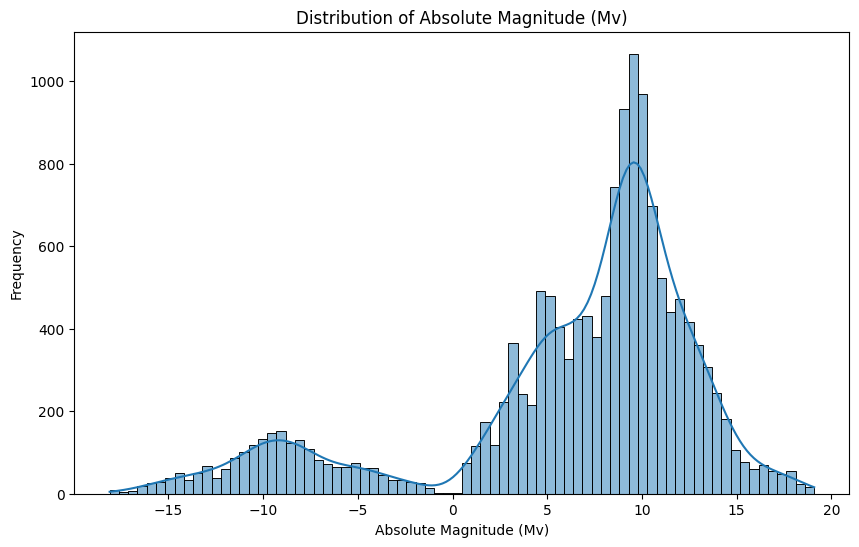

In [ ]:
# Plot the distribution of our regression target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Absolute Magnitude (Mv)'], kde=True)
plt.title('Distribution of Absolute Magnitude (Mv)')
plt.xlabel('Absolute Magnitude (Mv)')
plt.ylabel('Frequency')
plt.show()

**Violin Plot:**
In this step, a violin plot is created to show the distribution of **temperature** across different **star types**.
It helps visualize how temperature varies for each star type and also displays the spread, density, and range of the data in a single plot.


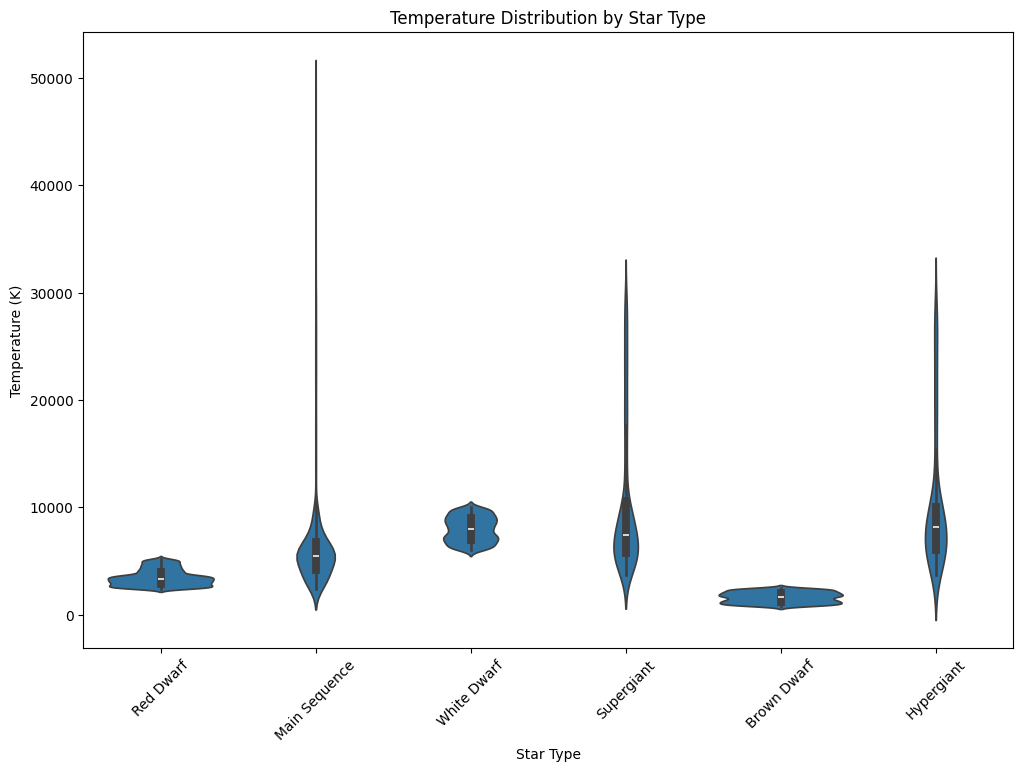

In [ ]:
# Violin Plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='Star Type', y='Temperature (K)', data=df)
plt.title('Temperature Distribution by Star Type')
plt.xticks(rotation=45)
plt.show()

**Correlation Heatmap:**
In this step, a correlation heatmap is created to show the relationship between different numerical features in the dataset.
It helps identify which variables are strongly or weakly correlated with each other, making it easier to select important features for model training.


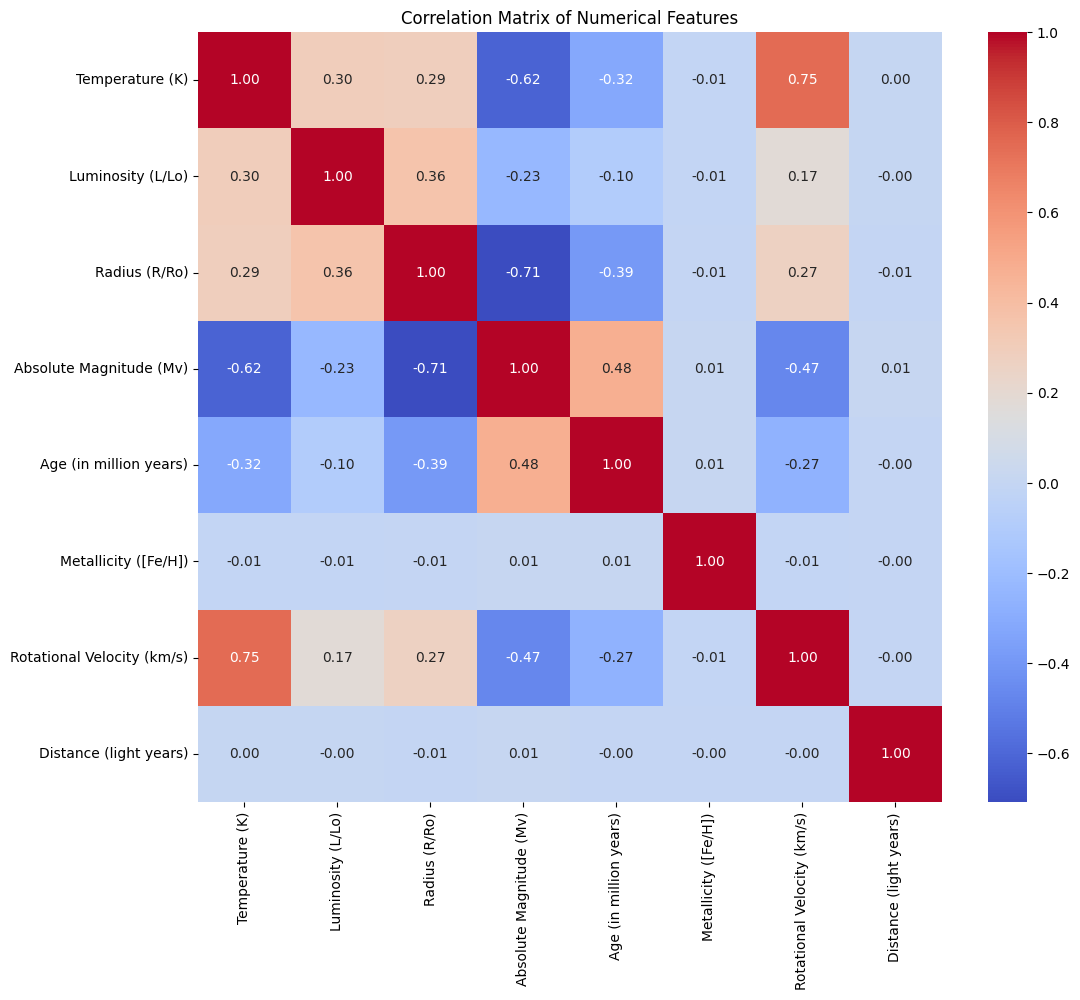

In [ ]:
# Create a correlation heatmap of numerical features
numerical_cols = ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute Magnitude (Mv)',
                  'Age (in million years)', 'Metallicity ([Fe/H])', 'Rotational Velocity (km/s)', 'Distance (light years)']

plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

To visualize relationships between features and the target, we plot Temperature against Absolute Magnitude. This scatterplot helps detect patterns, trends, or potential non-linear relationships.

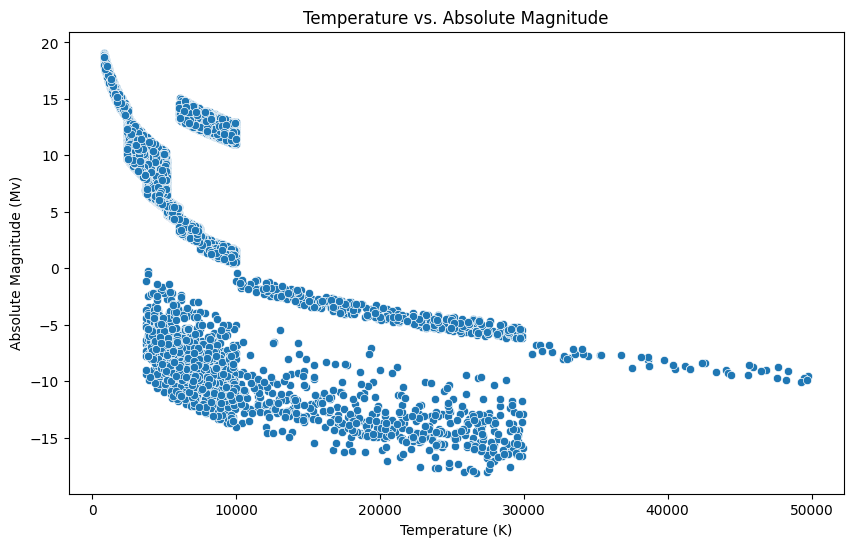

In [ ]:
# Visualize the relationship between 'Temperature' and 'Absolute Magnitude'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (K)', y='Absolute Magnitude (Mv)', data=df)
plt.title('Temperature vs. Absolute Magnitude')
plt.xlabel('Temperature (K)')
plt.ylabel('Absolute Magnitude (Mv)')
plt.show()

Finally, we look at the distribution of categorical feature 'Star Type'. Understanding the frequency of each type can guide feature encoding and ensure balanced representation in the dataset.

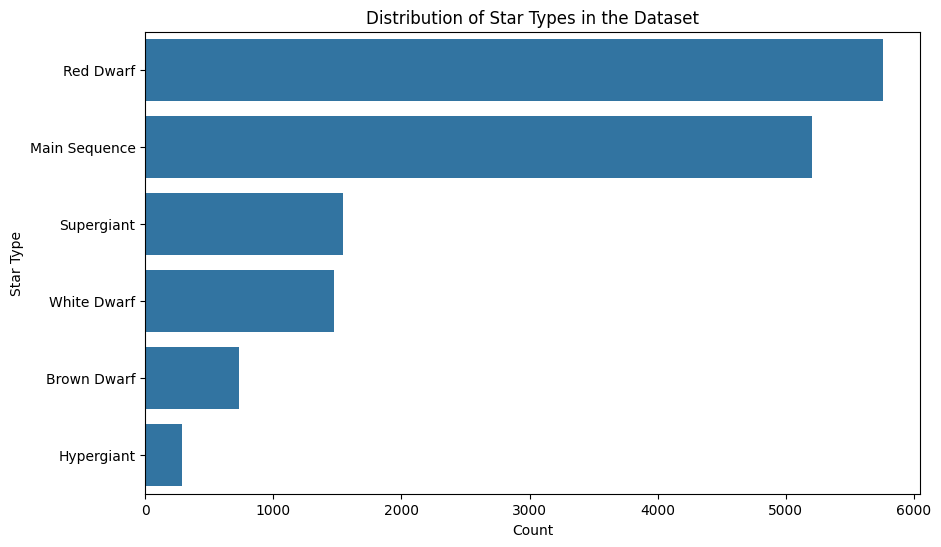

In [ ]:

plt.figure(figsize=(10, 6))
sns.countplot(y='Star Type', data=df, order=df['Star Type'].value_counts().index)
plt.title('Distribution of Star Types in the Dataset')
plt.xlabel('Count')
plt.ylabel('Star Type')
plt.show()

### Outlier Detection and Removal
**Outlier Detection and Removal (IQR Method):**
In this step, outliers in the **Luminosity** feature are detected and removed using the **Interquartile Range (IQR)** method.
The data is first log-transformed to reduce skewness, and then values lying outside the calculated lower and upper bounds are treated as outliers.
After applying this technique, the dataset size reduces, keeping only the valid and consistent records for further analysis.


In [ ]:
df['Luminosity_log'] = np.log1p(df['Luminosity (L/Lo)'])

Q1 = df['Luminosity_log'].quantile(0.25)
Q3 = df['Luminosity_log'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_processed = df[
    (df['Luminosity_log'] >= lower_bound) &
    (df['Luminosity_log'] <= upper_bound)
].copy()

print("Original number of rows: ", len(df))
print("Number of rows after removing outliers (by Luminosity_log IQR): ", len(df_processed))


Original number of rows:  15000
Number of rows after removing outliers (by Luminosity_log IQR):  12294


**Outlier Detection and Removal (Z-Score Method):**
In this step, outliers are identified using the **Z-score method** on the log-transformed luminosity values.
Data points with a Z-score greater than 3 or less than -3 are considered outliers and removed from the dataset.
This technique helps retain only the values that are statistically close to the mean, improving the data quality for model training.



In [ ]:
from scipy.stats import zscore

# Calculate z-scores for the log-transformed column
df['Luminosity_log_zscore'] = zscore(df['Luminosity_log'])

# Filter rows where |z-score| < 3
df_zscore = df[(df['Luminosity_log_zscore'].abs() < 3)].copy()

print("Rows after removing outliers by Z-score:", len(df_zscore))


Rows after removing outliers by Z-score: 14639


**Outlier Detection and Removal (Isolation Forest):**
In this step, the **Isolation Forest** algorithm is used to detect and remove outliers.
It is an unsupervised learning technique that isolates anomalies by randomly selecting features and split values.
Records identified as outliers are removed, and the remaining data represents normal patterns suitable for model building.


In [ ]:
from sklearn.ensemble import IsolationForest

# Use only numeric columns or selected features for Isolation Forest
features = ['Luminosity_log']  # you can add more if relevant

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['outlier_iso'] = iso_forest.fit_predict(df[features])

# Keep only non-outliers (label 1)
df_iso = df[df['outlier_iso'] == 1].copy()

print("Rows after Isolation Forest outlier removal:", len(df_iso))


Rows after Isolation Forest outlier removal: 14250


In [ ]:
#Comparative analysis of outlier removal methods
methods = {
    "Original": df,
    "IQR": df_processed,
    "Z-Score": df_zscore,
    "Isolation Forest": df_iso
}
comparison = []
for name, data in methods.items():
    comparison.append({
        "Method": name,
        "Rows Retained": len(data),
        "Mean": round(data['Luminosity_log'].mean(), 6),
        "Median": round(data['Luminosity_log'].median(), 6),
        "Std Dev": round(data['Luminosity_log'].std(), 6)
    })

comparison_df = pd.DataFrame(comparison)

print("\nComparative analysis of outlier removal methods:\n")
comparison_df



Comparative analysis of outlier removal methods:



,Method,Rows Retained,Mean,Median,Std Dev
0,Original,15000,2.137450,0.031004,4.576472
1,IQR,12294,0.221414,0.015854,0.453107
2,Z-Score,14639,1.755293,0.028111,3.918343
3,Isolation Forest,14250,1.583229,0.025267,3.767415


In [ ]:
# Using isolation forest
features = ['Luminosity_log']

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['outlier_iso'] = iso_forest.fit_predict(df[features])

df_clean = df[df['outlier_iso'] == 1].copy()

print(f"Rows after removing outliers by Isolation Forest: {len(df_clean)}")


Rows after removing outliers by Isolation Forest: 14250


In [ ]:
print(f"Outliers detected and removed: {len(df) - len(df_clean)}")


Outliers detected and removed: 750


### Encoding Categorical Features
Machine learning models require numerical input, so categorical features need to be converted into numeric form. Here, we use One-Hot Encoding to transform categorical columns such as Color, Spectral Class, Galaxy, and Constellation into binary vectors. The processed features are then combined with the numerical columns to create the final dataset for modeling."

In [ ]:
# Encoding
# Define features (X) and target (y)
X = df_clean.drop(columns=['Absolute Magnitude (Mv)', 'Star Type ID', 'Star Type'])
y = df_clean['Absolute Magnitude (Mv)']

categorical_cols = ['Color', 'Spectral Class', 'Galaxy', 'Constellation']

#One-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded_part = encoder.fit_transform(X[categorical_cols])


# Convert the sparse matrix to a dense array before creating the DataFrame
X_encoded_df = pd.DataFrame(X_encoded_part.toarray(), columns=encoder.get_feature_names_out(categorical_cols), index=X.index)

X_final = pd.concat([X.drop(columns=categorical_cols), X_encoded_df], axis=1)

print("Final preprocessed features (X) shape:", X_final.shape)
print("Final target (y) shape:", y.shape)

Final preprocessed features (X) shape: (14250, 38)
Final target (y) shape: (14250,)


### Train-Test Split
Next, we split our dataset into training and testing sets. The training set is used to fit the models, while the testing set evaluates their performance on unseen data. Here, 80% of the data is used for training and 20% for testing.

In [ ]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print("Data Splitting:")
print("Shape of X_train: ",X_train.shape)
print("Shape of X_test: ",X_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test: ",y_test.shape)

Data Splitting:
Shape of X_train:  (11400, 38)
Shape of X_test:  (2850, 38)
Shape of y_train:  (11400,)
Shape of y_test:  (2850,)


**Feature Scaling:**
In this step, different scaling techniques — **StandardScaler**, **MinMaxScaler**, and **RobustScaler** — are applied to normalize the features.
Scaling helps bring all numerical values to a similar range, improving model performance and stability.
Each method adjusts the data differently: StandardScaler standardizes values, MinMaxScaler rescales them between 0 and 1, and RobustScaler reduces the influence of outliers.


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Fit and transform on training data
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

print("Standard Scaled shape:", X_train_standard.shape)
print("MinMax Scaled shape:", X_train_minmax.shape)
print("Robust Scaled shape:", X_train_robust.shape)



Standard Scaled shape: (11400, 38)
MinMax Scaled shape: (11400, 38)
Robust Scaled shape: (11400, 38)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
# Select top 10 features
selector_kbest = SelectKBest(score_func=f_regression, k=10)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)
# Get selected feature names
selected_kbest = X_train.columns[selector_kbest.get_support()]
print("Top 10 features using SelectKBest:")
print(selected_kbest)

Top 10 features using SelectKBest:
Index(['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)',
       'Age (in million years)', 'Rotational Velocity (km/s)',
       'Luminosity_log', 'Luminosity_log_zscore', 'Color_Red',
       'Spectral Class_B', 'Spectral Class_M'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features_rf = importances.sort_values(ascending=False).head(10)
print("\nTop 10 features using Random Forest Importance:")
print(top_features_rf)


Top 10 features using Random Forest Importance:
Luminosity_log                3.363030e-01
Luminosity_log_zscore         2.960891e-01
Luminosity (L/Lo)             2.375480e-01
Radius (R/Ro)                 1.300596e-01
Age (in million years)        6.672925e-08
Metallicity ([Fe/H])          6.672657e-08
Rotational Velocity (km/s)    6.494616e-08
Distance (light years)        6.227113e-08
Temperature (K)               6.103303e-08
Constellation_Cassiopeia      1.212894e-08
dtype: float64


In [ ]:
from sklearn.linear_model import Lasso
import numpy as np
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train, y_train)
lasso_importance = pd.Series(np.abs(lasso.coef_), index=X_train.columns)
top_features_lasso = lasso_importance.sort_values(ascending=False).head(10)
print("\nTop 10 features using Lasso:")
print(top_features_lasso)


Top 10 features using Lasso:
Spectral Class_G      2.059047
Luminosity_log        1.674653
Spectral Class_K      1.451285
Color_Yellow          1.260666
Color_Yellow-White    0.904485
Color_Red             0.735642
Color_Orange          0.516994
Spectral Class_F      0.165311
Spectral Class_B      0.151930
Galaxy_Andromeda      0.041817
dtype: float64


In [ ]:
selected_features = selected_kbest.tolist()
X_train = X_train[selected_features]
X_test = X_test[selected_features]

**Linear Regression Model:**
In this step, a **Linear Regression** model is trained on the dataset to predict continuous target values.
After training, predictions are made on the test data, and the model’s performance is evaluated using metrics like **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² score**.
The results show good accuracy, indicating that the model fits the data well.


In [ ]:
print("Linear Regression")
lin_reg_model = LinearRegression()

print("Training the Linear Regression model.")
lin_reg_model.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_lin = lin_reg_model.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Model Evaluation (Linear Regression)")
print("Mean Absolute Error: ",mae_lin)
print("Mean Squared Error: ",mse_lin)
print("Root Mean Squared Error: ",rmse_lin)
print("R-squared (R²): ",r2_lin)

Linear Regression
Training the Linear Regression model.
Model training complete.
Predictions complete.
Model Evaluation (Linear Regression)
Mean Absolute Error:  1.7320855293481254
Mean Squared Error:  4.934924165868262
Root Mean Squared Error:  2.2214689207522715
R-squared (R²):  0.8721559605910336


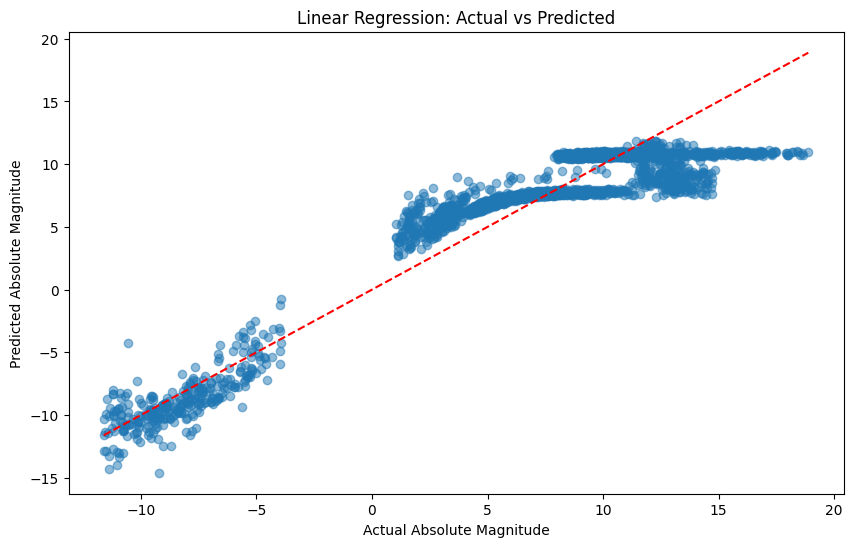

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

**Polynomial Regression Model:**
In this step, a **Polynomial Regression** model is implemented to capture non-linear relationships between features and the target variable.
The input features are transformed into polynomial terms of degree 2, and a Linear Regression model is trained on the transformed data.
Model performance is evaluated using MAE, MSE, RMSE, and R² score, showing improved results compared to simple linear regression.


In [ ]:
#Polynomial Regression
print("Polynomial Regression")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg_model = LinearRegression()

print("Training the polynomial regression model.")
poly_reg_model.fit(X_train_poly, y_train)
print("Model training complete.")

# Predictions
y_pred_poly = poly_reg_model.predict(X_test_poly)
print("Predictions complete.")

# Evaluation
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Model evaluation (Polynomial Regression)")
print("Mean Absolute Error: ",mae_poly)
print("Mean Squared Error: ",mse_poly)
print("Root Mean Squared Error: ",rmse_poly)
print("R-squared (R²): ",r2_poly)

Polynomial Regression
Training the polynomial regression model.
Model training complete.
Predictions complete.
Model evaluation (Polynomial Regression)
Mean Absolute Error:  1.4102689215529773
Mean Squared Error:  3.646690691417818
Root Mean Squared Error:  1.9096310354143855
R-squared (R²):  0.9055289093011007


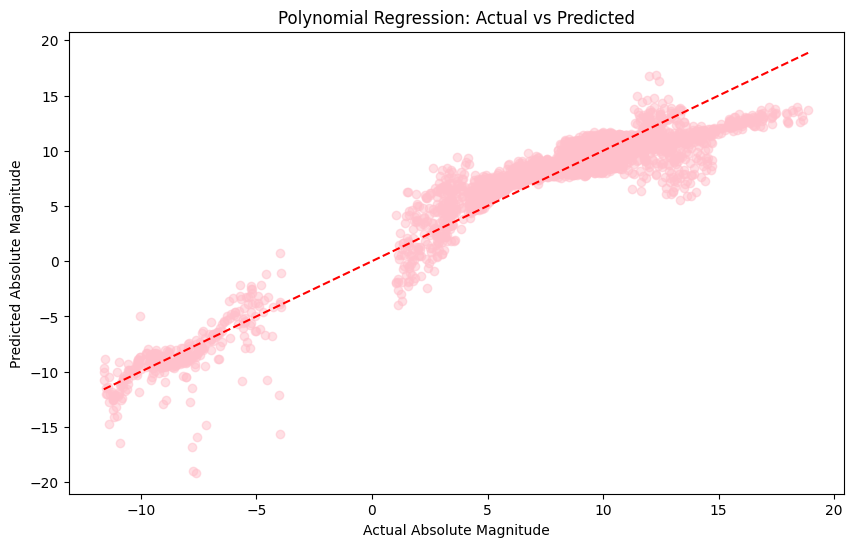

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_poly, alpha=0.5, color='pink')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

### Ridge Regression
Ridge Regression applies L2 regularization to reduce overfitting by penalizing large coefficients. We train the model on the training set, make predictions on the test set, and evaluate it using MAE, MSE, RMSE, and R-squared. A scatter plot of actual vs. predicted values shows how well the model fits the data while controlling complexity.

In [ ]:
# Ridge Regression
print("Ridge regression (L2 Regularization)")
ridge_model = Ridge(alpha=1.0)

print("Training the Ridge Regression model.")
ridge_model.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_ridge = ridge_model.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Model evaluation (Ridge Regression)")
print("Mean Absolute Error: ",mae_ridge)
print("Mean Squared Error: ",mse_ridge)
print("Root Mean Squared Error: ",rmse_ridge)
print("R-squared (R²): ",r2_ridge)

Ridge regression (L2 Regularization)
Training the Ridge Regression model.
Model training complete.
Predictions complete.
Model evaluation (Ridge Regression)
Mean Absolute Error:  1.732053532252326
Mean Squared Error:  4.9349247081735514
Root Mean Squared Error:  2.221469042812335
R-squared (R²):  0.8721559465420844


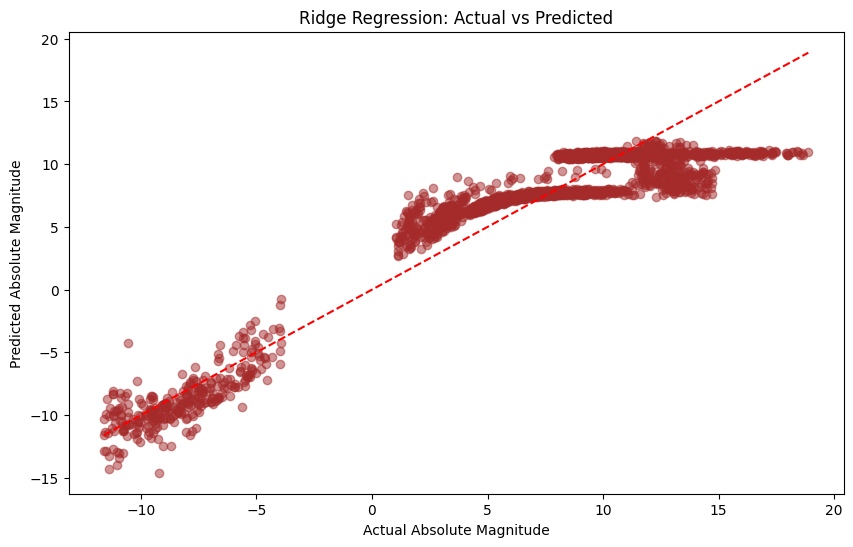

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='brown')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()


### Lasso Regression
Lasso Regression uses L1 regularization, which can shrink some coefficients to zero and perform feature selection. The model is trained on the training set, predictions are made on the test set, and performance is evaluated using MAE, MSE, RMSE, and R-squared. The scatter plot of actual vs. predicted values helps visualize the fit and highlights the impact of regularization.

In [ ]:
#Lasso Regression
print("Lasso regression (L1 Regularization) ")
lasso_model = Lasso(alpha=0.01)

print("Training the Lasso regression model.")
lasso_model.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_lasso = lasso_model.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Model evaluation (Lasso Regression)")
print("Mean Absolute Error: ",mae_lasso)
print("Mean Squared Error: ",mse_lasso)
print("Root Mean Squared Error: ",rmse_lasso)
print("R-squared (R²): ",r2_lasso)

Lasso regression (L1 Regularization) 
Training the Lasso regression model.
Model training complete.
Predictions complete.
Model evaluation (Lasso Regression)
Mean Absolute Error:  1.7308794517361688
Mean Squared Error:  4.942385370623939
Root Mean Squared Error:  2.223147626817423
R-squared (R²):  0.8719626707809448


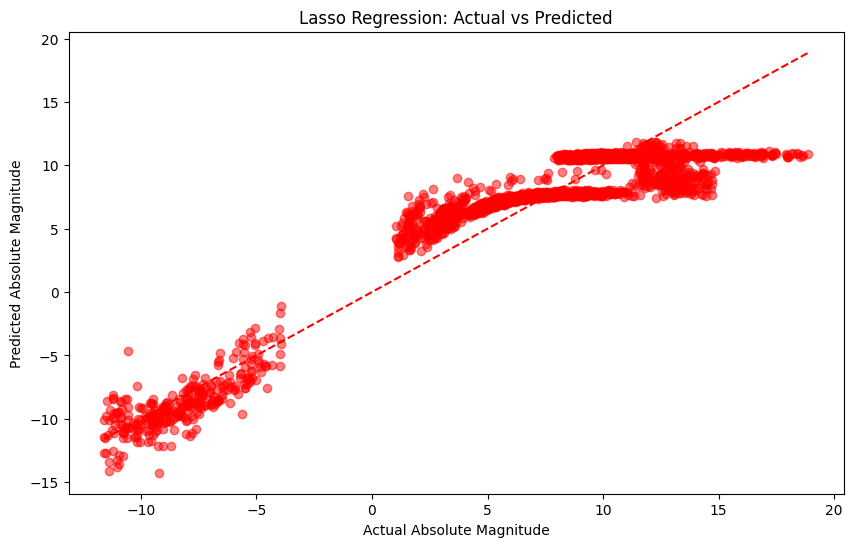

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

### ElasticNet Regression
ElasticNet Regression combines L1 and L2 regularization, balancing between feature selection and coefficient shrinkage. The model is trained on the training set, predictions are generated on the test set, and performance is measured using MAE, MSE, RMSE, and R-squared. A scatter plot of actual vs. predicted values shows how well the model generalizes and balances bias-variance trade-off.

In [ ]:
#ElasticNet Regression
print("ElasticNet regression")
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.5)

print("Training the ElasticNet model.")
elastic_model.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_elastic = elastic_model.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("Model evaluation (ElasticNet Regression)")
print("Mean Absolute Error: ",mae_elastic)
print("Mean Squared Error: ",mse_elastic)
print("Root Mean Squared Error: ",rmse_elastic)
print("R-squared (R²): ",r2_elastic)

ElasticNet regression
Training the ElasticNet model.
Model training complete.
Predictions complete.
Model evaluation (ElasticNet Regression)
Mean Absolute Error:  1.7301987638460592
Mean Squared Error:  4.941329681562581
Root Mean Squared Error:  2.222910182972443
R-squared (R²):  0.8719900194390858


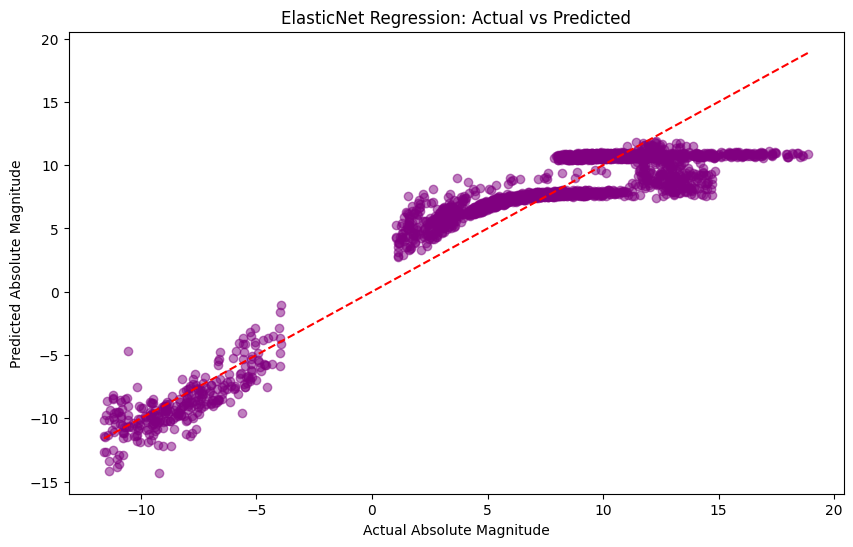

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_elastic, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("ElasticNet Regression: Actual vs Predicted")
plt.show()

**RANSAC Regression Model:**
In this step, the **RANSAC (Random Sample Consensus) Regression** model is trained to handle outliers in the data.
It repeatedly fits the model on random subsets of data and selects the best fit based on inliers.
However, the evaluation results show very high error and a negative R² score, indicating poor performance—possibly due to unsuitable parameter settings or excessive outlier influence.


In [ ]:
# RANSAC Regression
ransac = RANSACRegressor(LinearRegression(), random_state=42)

print("Training the RANSAC Regression model.")
ransac.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_ransac = ransac.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_ransac = mean_squared_error(y_test, y_pred_ransac)
mae_ransac = mean_absolute_error(y_test, y_pred_ransac)
rmse_ransac = np.sqrt(mse_ransac)
r2_ransac = r2_score(y_test, y_pred_ransac)

print("\nModel evaluation (RANSAC Regression)")
print("Mean Absolute Error: ", mae_ransac)
print("Mean Squared Error: ", mse_ransac)
print("Root Mean Squared Error: ", rmse_ransac)
print("R-squared (R²): ",r2_ransac)


Training the RANSAC Regression model.
Model training complete.
Predictions complete.

Model evaluation (RANSAC Regression)
Mean Absolute Error:  284.9628990691355
Mean Squared Error:  1049956.830697511
Root Mean Squared Error:  1024.6740119167223
R-squared (R²):  -27199.15909662701


In [ ]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

print("Training the decision tree regression model.")
dt.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_dt = dt.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nModel evaluation (Decision Tree Regression)")
print("Mean Absolute Error: ", mae_dt)
print("Mean Squared Error: ", mse_dt)
print("Root Mean Squared Error: ", rmse_dt)
print("R-squared (R²): ", r2_dt)


Training the decision tree regression model.
Model training complete.
Predictions complete.

Model evaluation (Decision Tree Regression)
Mean Absolute Error:  0.0019472974622749288
Mean Squared Error:  2.1769113532873106e-05
Root Mean Squared Error:  0.004665738262362464
R-squared (R²):  0.9999994360498126


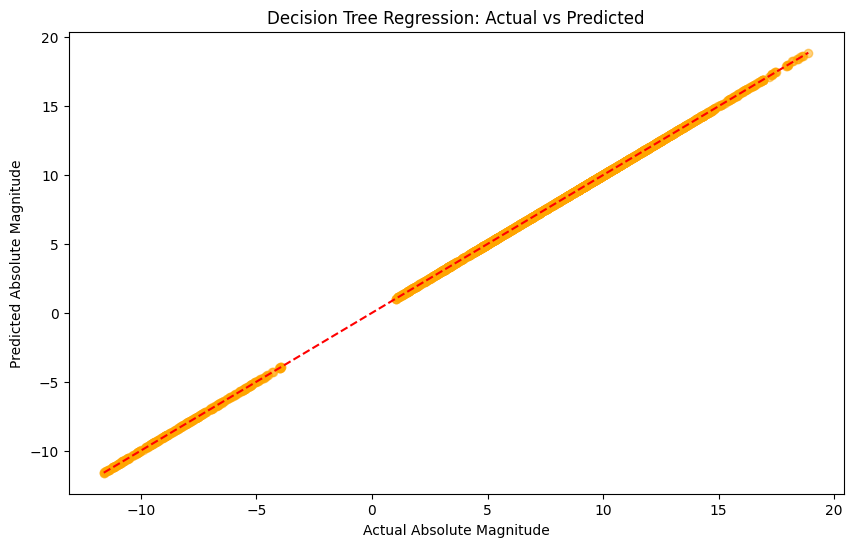

In [ ]:
# Decision Tree Regression Visualization
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.show()


In [ ]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

print("Training the Random Forest Regression model.")
rf.fit(X_train, y_train)
print("Model training complete.")

# Predictions
y_pred_rf = rf.predict(X_test)
print("Predictions complete.")

# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nModel evaluation (Random Forest Regression)")
print("Mean Absolute Error: ", mae_rf)
print("Mean Squared Error: ", mse_rf)
print("Root Mean Squared Error: ", rmse_rf)
print("R-squared (R²): ", r2_rf)


Training the Random Forest Regression model.
Model training complete.
Predictions complete.

Model evaluation (Random Forest Regression)
Mean Absolute Error:  0.001237910122018983
Mean Squared Error:  6.274464031371987e-06
Root Mean Squared Error:  0.002504888027711416
R-squared (R²):  0.9999998374538697


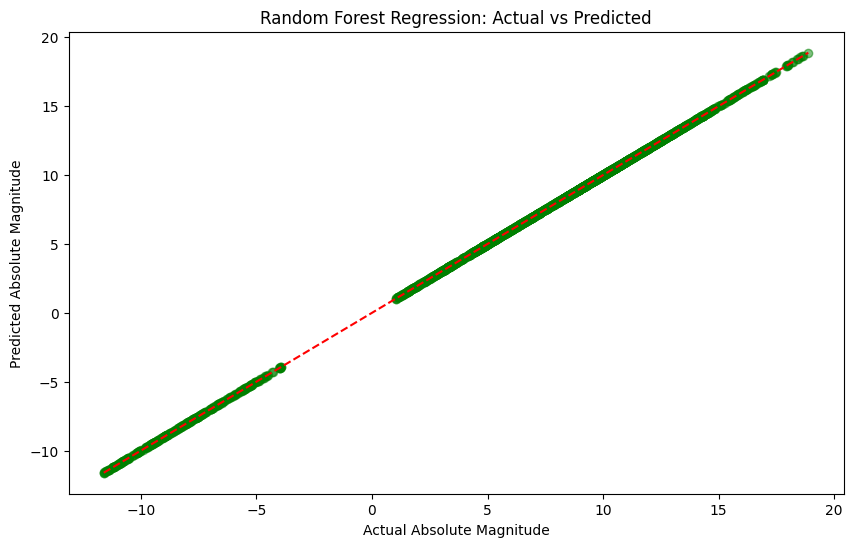

In [ ]:
# Random Forest Regression Visualization
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Absolute Magnitude")
plt.ylabel("Predicted Absolute Magnitude")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.show()


### Model Performance Summary
After training all regression models, we summarize their performance in a single table. This table shows the R² score, Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) for each model, allowing easy comparison of accuracy and error metrics to identify the best-performing regression approach.

In [ ]:
#Summary table
summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'RANSAC Regression',
        'Decision Tree Regression',
        'Random Forest Regression'
    ],
    'R² Score': [
        r2_lin, r2_poly, r2_ridge, r2_lasso, r2_elastic, r2_ransac, r2_dt, r2_rf
    ],
    'MSE': [
        mse_lin, mse_poly, mse_ridge, mse_lasso, mse_elastic, mse_ransac, mse_dt, mse_rf
    ],
    'MAE': [
        mae_lin, mae_poly, mae_ridge, mae_lasso, mae_elastic, mae_ransac, mae_dt, mae_rf
    ],
    'RMSE': [
        rmse_lin, rmse_poly, rmse_ridge, rmse_lasso, rmse_elastic, rmse_ransac, rmse_dt, rmse_rf
    ]
})

print("Model Performance Summary")
display(summary)


Model Performance Summary


,Model,R² Score,MSE,MAE,RMSE
0,Linear Regression,0.872156,4.934924e+00,1.732086,2.221469
1,Polynomial Regression,0.905529,3.646691e+00,1.410269,1.909631
2,Ridge Regression,0.872156,4.934925e+00,1.732054,2.221469
3,Lasso Regression,0.871963,4.942385e+00,1.730879,2.223148
4,ElasticNet Regression,0.871990,4.941330e+00,1.730199,2.222910
5,RANSAC Regression,-27199.159097,1.049957e+06,284.962899,1024.674012
6,Decision Tree Regression,0.999999,2.176911e-05,0.001947,0.004666
7,Random Forest Regression,1.000000,6.274464e-06,0.001238,0.002505


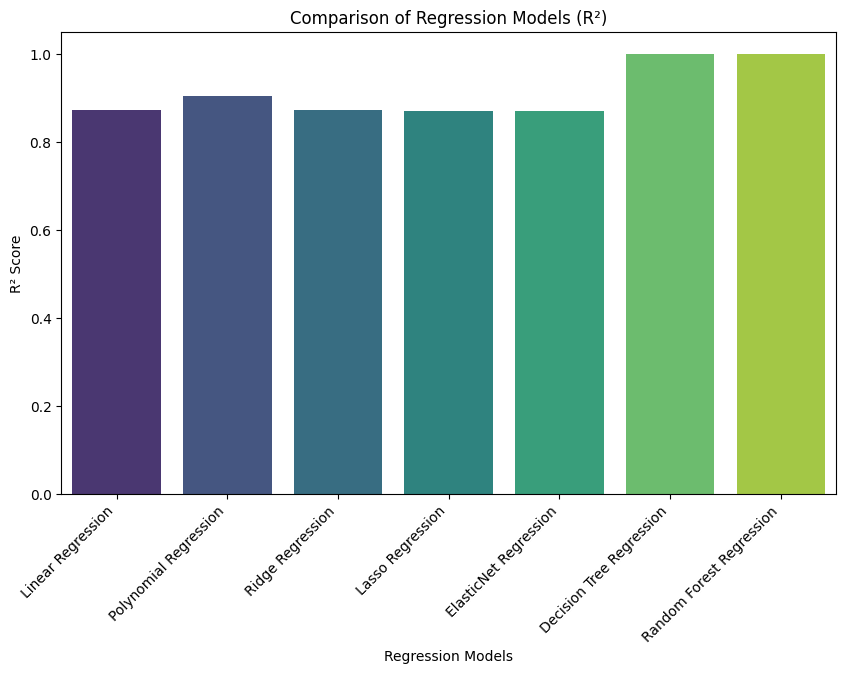

In [ ]:
summary_filtered = summary[summary['Model'] != 'RANSAC Regression']

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R² Score', hue='Model', data=summary_filtered, palette='viridis', legend=False)
plt.title("Comparison of Regression Models (R²)")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.show()


In [ ]:
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor

# Bagging Regressor
bag_reg = BaggingRegressor(random_state=42)
bag_reg.fit(X_train, y_train)
y_pred_bag = bag_reg.predict(X_test)

mse_bag = mean_squared_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)
print("Bagging Regressor - MSE:", mse_bag, ", R²:", r2_bag)

# AdaBoost Regressor
ada_reg = AdaBoostRegressor(random_state=42)
ada_reg.fit(X_train, y_train)
y_pred_ada = ada_reg.predict(X_test)
print("AdaBoost Regressor - MSE:", mean_squared_error(y_test, y_pred_ada), ", R²:", r2_score(y_test, y_pred_ada))

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)
print("Gradient Boosting Regressor - MSE:", mean_squared_error(y_test, y_pred_gb), ", R²:", r2_score(y_test, y_pred_gb))


Bagging Regressor - MSE: 1.1874756311876423e-05 , R²: 0.9999996923728182
AdaBoost Regressor - MSE: 0.12159995538739714 , R²: 0.9968498341684365
Gradient Boosting Regressor - MSE: 0.0025136369592904206 , R²: 0.9999348817749407


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Define features (X) and target (y)
X_cls = df_processed.drop(columns=['Star Type ID', 'Star Type', 'Absolute Magnitude (Mv)'])
y_cls = df_processed['Star Type']

In [ ]:
# Identify categorical columns
categorical_cols_cls = ['Color', 'Spectral Class', 'Galaxy', 'Constellation']

# One-hot encode categorical features
encoder_cls = OneHotEncoder(handle_unknown='ignore')
X_encoded_cls = encoder_cls.fit_transform(X_cls[categorical_cols_cls])

# Convert to DataFrame
X_encoded_cls_df = pd.DataFrame(
    X_encoded_cls.toarray(),
    columns=encoder_cls.get_feature_names_out(categorical_cols_cls),
    index=X_cls.index
)

# Combine encoded + numeric features
X_final_cls = pd.concat([X_cls.drop(columns=categorical_cols_cls), X_encoded_cls_df], axis=1)


In [ ]:
# Train-test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split( X_final_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print("Shape of X_train:", X_train_cls.shape)
print("Shape of X_test:", X_test_cls.shape)
print("Shape of y_train:", y_train_cls.shape)
print("Shape of y_test:", y_test_cls.shape)


Shape of X_train: (9835, 32)
Shape of X_test: (2459, 32)
Shape of y_train: (9835,)
Shape of y_test: (2459,)


In [ ]:

# Initialize scalers
standard_scaler_cls = StandardScaler()
minmax_scaler_cls = MinMaxScaler()
robust_scaler_cls = RobustScaler()

# Fit on training data and transform
X_train_standard_cls = standard_scaler_cls.fit_transform(X_train_cls)
X_test_standard_cls = standard_scaler_cls.transform(X_test_cls)

X_train_minmax_cls = minmax_scaler_cls.fit_transform(X_train_cls)
X_test_minmax_cls = minmax_scaler_cls.transform(X_test_cls)

X_train_robust_cls = robust_scaler_cls.fit_transform(X_train_cls)
X_test_robust_cls = robust_scaler_cls.transform(X_test_cls)

print("Standard Scaled shape:", X_train_standard_cls.shape)
print("MinMax Scaled shape:", X_train_minmax_cls.shape)
print("Robust Scaled shape:", X_train_robust_cls.shape)

Standard Scaled shape: (9835, 32)
MinMax Scaled shape: (9835, 32)
Robust Scaled shape: (9835, 32)


In [ ]:

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression model.")
log_reg.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_log = log_reg.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_log = accuracy_score(y_test_cls, y_pred_log)
prec_log = precision_score(y_test_cls, y_pred_log, average='weighted', zero_division=0)
rec_log = recall_score(y_test_cls, y_pred_log, average='weighted', zero_division=0)
f1_log = f1_score(y_test_cls, y_pred_log, average='weighted', zero_division=0)

print("\nModel Evaluation (Logistic Regression)")
print("Accuracy: ", acc_log)
print("Precision: ", prec_log)
print("Recall: ", rec_log)
print("F1 Score: ", f1_log)

Training Logistic Regression model.
Model training complete.
Predictions complete.

Model Evaluation (Logistic Regression)
Accuracy:  0.9028060187067913
Precision:  0.9148367189171959
Recall:  0.9028060187067913
F1 Score:  0.9003857213368981


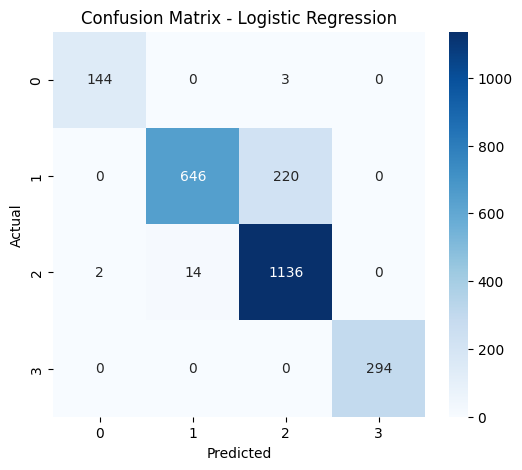

In [ ]:
# Confusion Matrix Visualization
cm_log = confusion_matrix(y_test_cls, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree model.")
dt.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_dt = dt.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_dt = accuracy_score(y_test_cls, y_pred_dt)
prec_dt = precision_score(y_test_cls, y_pred_dt, average='weighted', zero_division=0)
rec_dt = recall_score(y_test_cls, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test_cls, y_pred_dt, average='weighted', zero_division=0)

print("\nModel Evaluation (Decision Tree)")
print("Accuracy: ", acc_dt)
print("Precision: ", prec_dt)
print("Recall: ", rec_dt)
print("F1 Score: ", f1_dt)


Training Decision Tree model.
Model training complete.
Predictions complete.

Model Evaluation (Decision Tree)
Accuracy:  0.8784058560390403
Precision:  0.8788541637267795
Recall:  0.8784058560390403
F1 Score:  0.8785279542974989


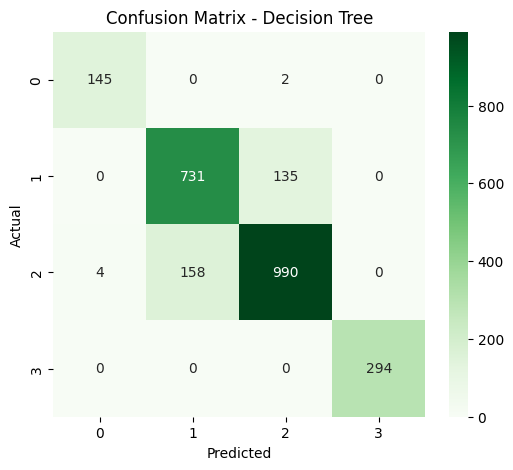

In [ ]:

# Confusion Matrix Visualization
cm_dt = confusion_matrix(y_test_cls, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

print("Training Random Forest model.")
rf.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_rf = rf.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_rf = accuracy_score(y_test_cls, y_pred_rf)
prec_rf = precision_score(y_test_cls, y_pred_rf, average='weighted', zero_division=0)
rec_rf = recall_score(y_test_cls, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test_cls, y_pred_rf, average='weighted', zero_division=0)

print("\nModel Evaluation (Random Forest)")
print("Accuracy: ", acc_rf)
print("Precision: ", prec_rf)
print("Recall: ", rec_rf)
print("F1 Score: ", f1_rf)


Training Random Forest model.
Model training complete.
Predictions complete.

Model Evaluation (Random Forest)
Accuracy:  0.909312728751525
Precision:  0.9185275126780529
Recall:  0.909312728751525
F1 Score:  0.9074140271926225


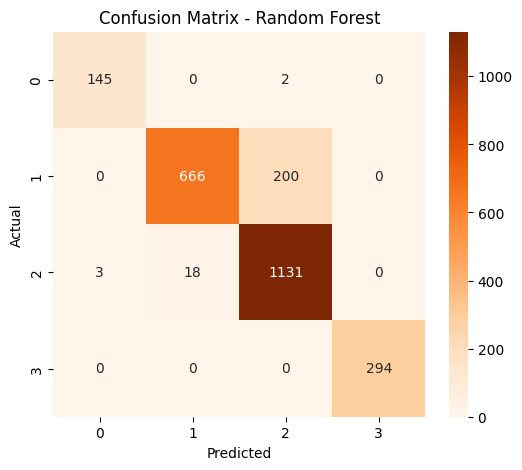

In [ ]:
# Confusion Matrix Visualization
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

print("Training KNN model.")
knn.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_knn = knn.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_knn = accuracy_score(y_test_cls, y_pred_knn)
prec_knn = precision_score(y_test_cls, y_pred_knn, average='weighted', zero_division=0)
rec_knn = recall_score(y_test_cls, y_pred_knn, average='weighted', zero_division=0)
f1_knn = f1_score(y_test_cls, y_pred_knn, average='weighted', zero_division=0)

print("\nModel Evaluation (KNN)")
print("Accuracy: ", acc_knn)
print("Precision: ", prec_knn)
print("Recall: ", rec_knn)
print("F1 Score: ", f1_knn)


Training KNN model.
Model training complete.
Predictions complete.

Model Evaluation (KNN)
Accuracy:  0.8291988613257422
Precision:  0.8348159532386794
Recall:  0.8291988613257422
F1 Score:  0.8249529435993842


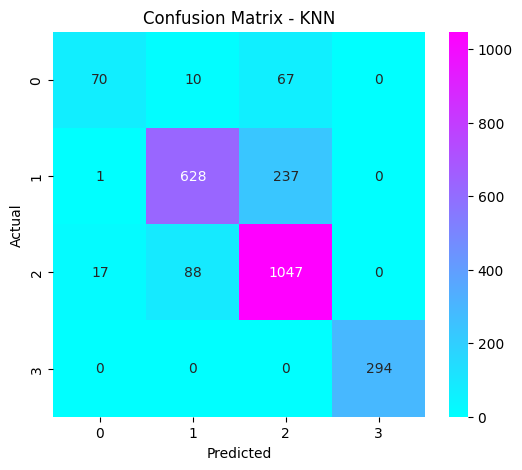

In [ ]:
# Confusion Matrix Visualization - KNN
cm_knn = confusion_matrix(y_test_cls, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='cool')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Support Vector Machine
svm = SVC(random_state=42)

print("Training SVM model.")
svm.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_svm = svm.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_svm = accuracy_score(y_test_cls, y_pred_svm)
prec_svm = precision_score(y_test_cls, y_pred_svm, average='weighted', zero_division=0)
rec_svm = recall_score(y_test_cls, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test_cls, y_pred_svm, average='weighted', zero_division=0)

print("\nModel Evaluation (SVM)")
print("Accuracy: ", acc_svm)
print("Precision: ", prec_svm)
print("Recall: ", rec_svm)
print("F1 Score: ", f1_svm)


Training SVM model.
Model training complete.
Predictions complete.

Model Evaluation (SVM)
Accuracy:  0.9036193574623831
Precision:  0.9194214418036546
Recall:  0.9036193574623831
F1 Score:  0.9013395697924312


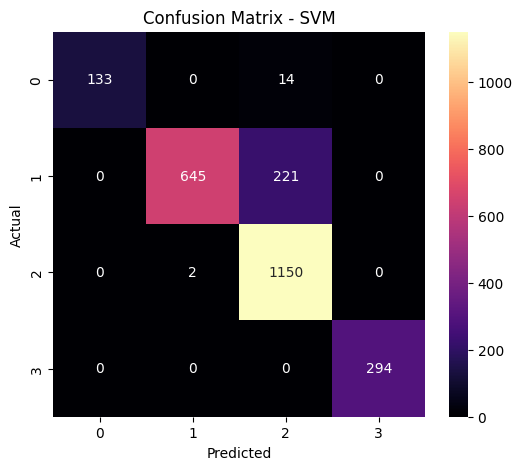

In [ ]:
# Confusion Matrix Visualization - SVM
cm_svm = confusion_matrix(y_test_cls, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='magma')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Naive Bayes Classification
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

print("Training Naive Bayes model.")
nb.fit(X_train_standard_cls, y_train_cls)
print("Model training complete.")

# Predictions
y_pred_nb = nb.predict(X_test_standard_cls)
print("Predictions complete.")

# Evaluation
acc_nb = accuracy_score(y_test_cls, y_pred_nb)
prec_nb = precision_score(y_test_cls, y_pred_nb, average='weighted', zero_division=0)
rec_nb = recall_score(y_test_cls, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test_cls, y_pred_nb, average='weighted', zero_division=0)

print("\nModel Evaluation (Naive Bayes)")
print("Accuracy: ", acc_nb)
print("Precision: ", prec_nb)
print("Recall: ", rec_nb)
print("F1 Score: ", f1_nb)


Training Naive Bayes model.
Model training complete.
Predictions complete.

Model Evaluation (Naive Bayes)
Accuracy:  0.8466856445709638
Precision:  0.8798126387716808
Recall:  0.8466856445709638
F1 Score:  0.8383550363551794


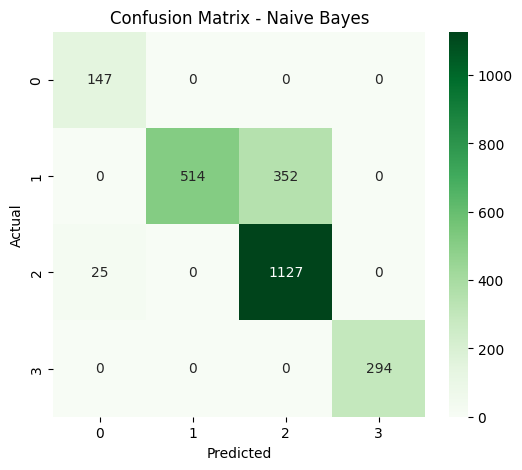

In [ ]:
# Confusion Matrix Visualization - Naive Bayes
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Create a summary DataFrame
summary_cls = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'K-Nearest Neighbors (KNN)',
        'Support Vector Machine (SVM)',
        'Naive Bayes Classifier'
    ],
    'Accuracy': [
        acc_log, acc_dt, acc_rf, acc_knn, acc_svm, acc_nb
    ],
    'Precision': [
        prec_log, prec_dt, prec_rf, prec_knn, prec_svm, prec_nb
    ],
    'Recall': [
        rec_log, rec_dt, rec_rf, rec_knn, rec_svm, rec_nb
    ],
    'F1 Score': [
        f1_log, f1_dt, f1_rf, f1_knn, f1_svm, f1_nb
    ]
})

# Display summary table
print("Classification Model Performance Summary:\n")
summary_cls

Classification Model Performance Summary:



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.902806,0.914837,0.902806,0.900386
1,Decision Tree Classifier,0.878406,0.878854,0.878406,0.878528
2,Random Forest Classifier,0.909313,0.918528,0.909313,0.907414
3,K-Nearest Neighbors (KNN),0.829199,0.834816,0.829199,0.824953
4,Support Vector Machine (SVM),0.903619,0.919421,0.903619,0.901340
5,Naive Bayes Classifier,0.846686,0.879813,0.846686,0.838355


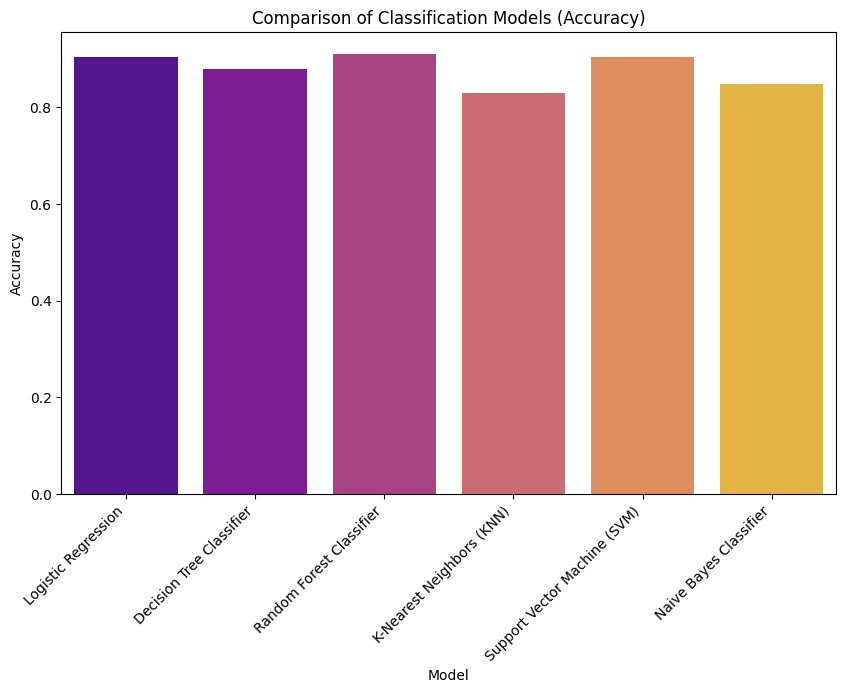

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=summary_cls, palette='plasma', legend=False)
plt.title("Comparison of Classification Models (Accuracy)")
plt.xticks(rotation=45, ha='right')
plt.show()


Among all the classification models applied, the Random Forest Classifier achieved the highest accuracy (≈0.91), indicating strong overall performance and good generalization on the dataset.
The Support Vector Machine (≈0.90) and Logistic Regression (≈0.90) also performed competitively, showing that linear models and kernel-based approaches handled the data effectively.
The Decision Tree Classifier achieved moderate accuracy (≈0.87), while Naive Bayes (≈0.84) and K-Nearest Neighbors (≈0.82) showed relatively lower performance.

Overall, ensemble-based methods like Random Forest provided the best results, combining stability, robustness, and better prediction accuracy compared to individual classifiers.

In [ ]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Bagging Classifier
bag_cls = BaggingClassifier(random_state=42)
bag_cls.fit(X_train_standard_cls, y_train_cls)
y_pred_bag = bag_cls.predict(X_test_standard_cls)

acc_bag = accuracy_score(y_test_cls, y_pred_bag)
print("Bagging Classifier Accuracy:", acc_bag)

# AdaBoost Classifier
ada_cls = AdaBoostClassifier(random_state=42)
ada_cls.fit(X_train_standard_cls, y_train_cls)
y_pred_ada = ada_cls.predict(X_test_standard_cls)

acc_ada = accuracy_score(y_test_cls, y_pred_ada)
print("AdaBoost Classifier Accuracy:", acc_ada)

# Gradient Boosting Classifier
gb_cls = GradientBoostingClassifier(random_state=42)
gb_cls.fit(X_train_standard_cls, y_train_cls)
y_pred_gb = gb_cls.predict(X_test_standard_cls)

acc_gb = accuracy_score(y_test_cls, y_pred_gb)
print("Gradient Boosting Classifier Accuracy:", acc_gb)


Bagging Classifier Accuracy: 0.8889792598617324
AdaBoost Classifier Accuracy: 0.9121594143960959
Gradient Boosting Classifier Accuracy: 0.909312728751525


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import scipy.cluster.hierarchy as sch

In [ ]:
# Data preparation for clustering
# Drop unnecessary or target columns
X_cluster = df_iso.drop(columns=['Star Type ID', 'Star Type'])

# Encode categorical columns
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
print("Data prepared for clustering. \nShape:", X_scaled.shape)

Data prepared for clustering. 
Shape: (14250, 35)


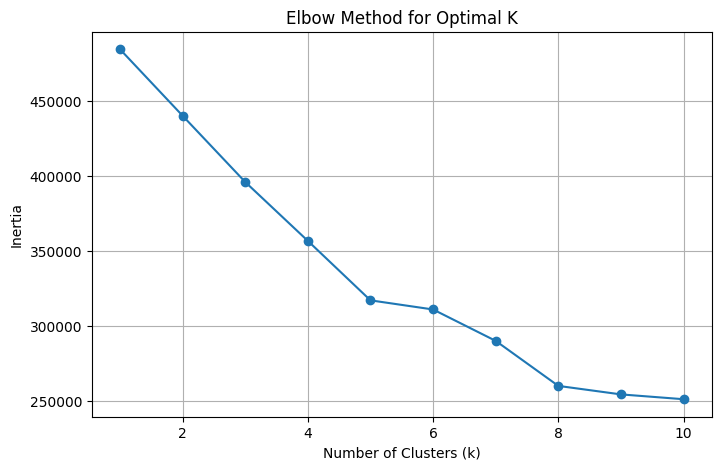

In [ ]:
# Elbow Method for K-Means
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


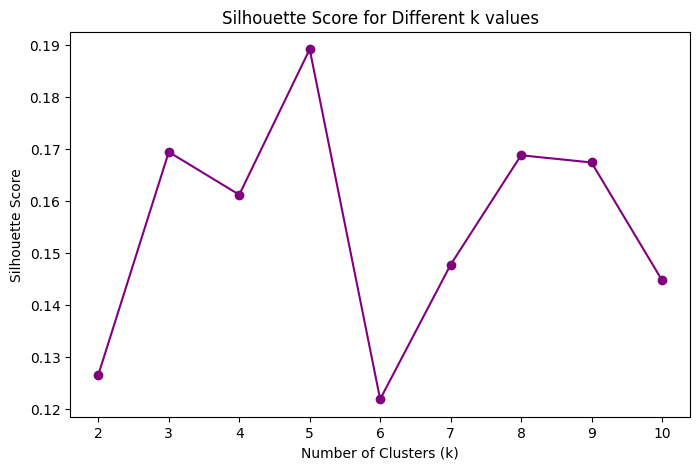


Best k based on Silhouette Score: 5


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='purple')
plt.title("Silhouette Score for Different k values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = range(2, 11)[sil_scores.index(max(sil_scores))]
print("\nBest k based on Silhouette Score:", best_k)


In [ ]:
# K-Means Clustering
print("Training K-Means model.")
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("Model training complete.")

# Evaluation
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

print("\nModel Evaluation (K-Means Clustering)")
print("Silhouette Score:", sil_kmeans)
print("Calinski–Harabasz Index:", ch_kmeans)
print("Davies–Bouldin Index:", db_kmeans)

Training K-Means model.
Model training complete.

Model Evaluation (K-Means Clustering)
Silhouette Score: 0.18914560925720994
Calinski–Harabasz Index: 1879.6121459979777
Davies–Bouldin Index: 1.857589831872731


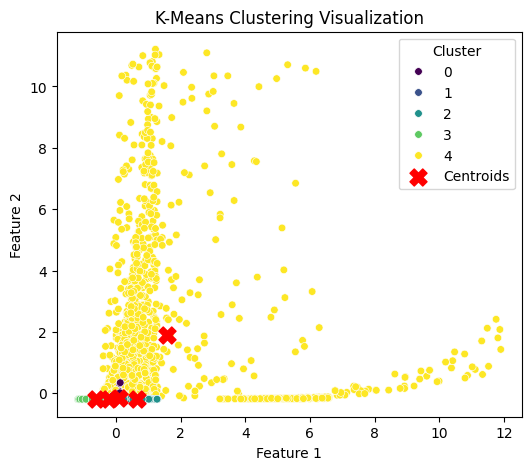

In [ ]:
# Cluster Visualization
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1],
                hue=kmeans_labels, palette='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=150, label='Centroids')
plt.title("K-Means Clustering Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title='Cluster', loc='best')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Hierarchical Clustering (Agglomerative Clustering)
# Ward Linkage
print("Training Hierarchical Clustering model (Ward Linkage).")
linkage_ward = linkage(X_scaled, method='ward')
print("Linkage matrix created. (Ward Linkage)")

# Form flat clusters
labels_ward = fcluster(linkage_ward, 5, criterion='maxclust')
print("Clusters formed from dendrogram.")

# Evaluation
sil_ward = silhouette_score(X_scaled, labels_ward)
ch_ward = calinski_harabasz_score(X_scaled, labels_ward)
db_ward = davies_bouldin_score(X_scaled, labels_ward)

print("\nModel Evaluation (Hierarchical Clustering)(Ward Linkage)")
print("Silhouette Score(Ward Linkage):", sil_ward)
print("Calinski–Harabasz Index(Ward Linkage):", ch_ward)
print("Davies–Bouldin Index(Ward Linkage):", db_ward)




Training Hierarchical Clustering model (Ward Linkage).
Linkage matrix created. (Ward Linkage)
Clusters formed from dendrogram.

Model Evaluation (Hierarchical Clustering)(Ward Linkage)
Silhouette Score(Ward Linkage): 0.17138017850336879
Calinski–Harabasz Index(Ward Linkage): 1918.7105463949865
Davies–Bouldin Index(Ward Linkage): 1.9250595113917501


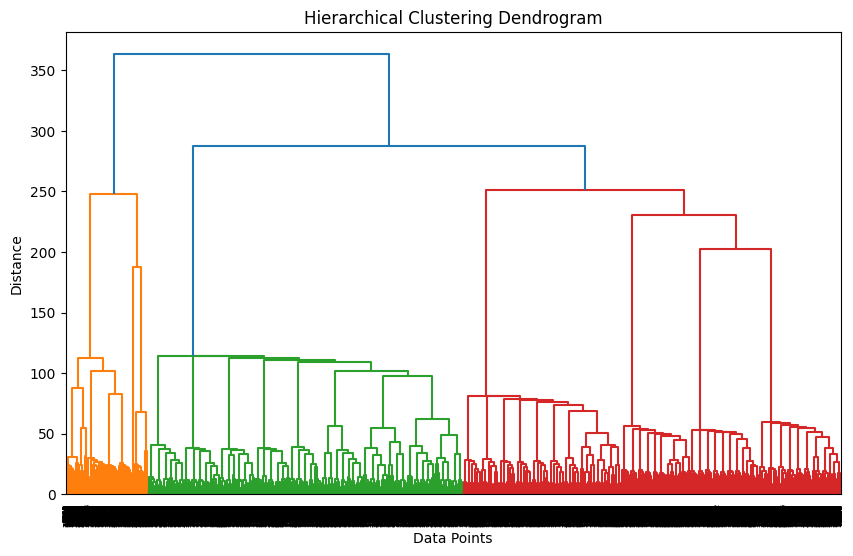

In [ ]:

# Dendrogram Visualization
plt.figure(figsize=(10, 6))
dendrogram(linkage_ward)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

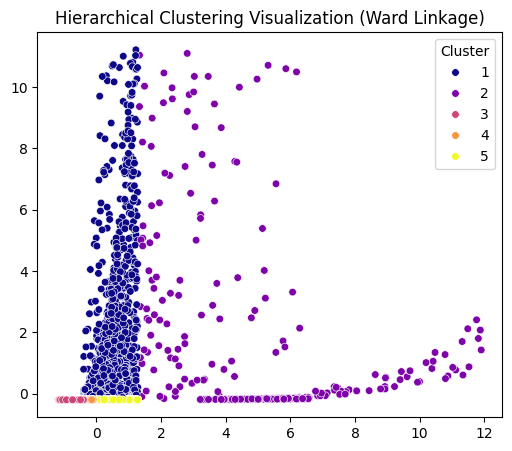

In [ ]:
# Cluster Visualization
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_ward, palette='plasma', s=30)
plt.title("Hierarchical Clustering Visualization (Ward Linkage)")
plt.legend(title='Cluster', loc='best')
plt.show()

In [ ]:
# Hierarchical Clustering (Agglomerative Clustering)
# Complete Linkage
print("Training Hierarchical Clustering model (Complete Linkage).")
linkage_complete = linkage(X_scaled, method='complete')
print("Linkage matrix created. (Complete Linkage)")

# Form flat clusters
labels_complete = fcluster(linkage_ward, 5, criterion='maxclust')
print("Clusters formed from dendrogram.")

# Evaluation
sil_complete = silhouette_score(X_scaled, labels_complete)
ch_complete = calinski_harabasz_score(X_scaled, labels_complete)
db_complete = davies_bouldin_score(X_scaled, labels_complete)

print("\nModel Evaluation (Hierarchical Clustering)(Ward Linkage)")
print("Silhouette Score(Ward Linkage):", sil_complete)
print("Calinski–Harabasz Index(Ward Linkage):", ch_complete)
print("Davies–Bouldin Index(Ward Linkage):", db_complete)




Training Hierarchical Clustering model (Complete Linkage).
Linkage matrix created. (Complete Linkage)
Clusters formed from dendrogram.

Model Evaluation (Hierarchical Clustering)(Ward Linkage)
Silhouette Score(Ward Linkage): 0.17138017850336879
Calinski–Harabasz Index(Ward Linkage): 1918.7105463949865
Davies–Bouldin Index(Ward Linkage): 1.9250595113917501


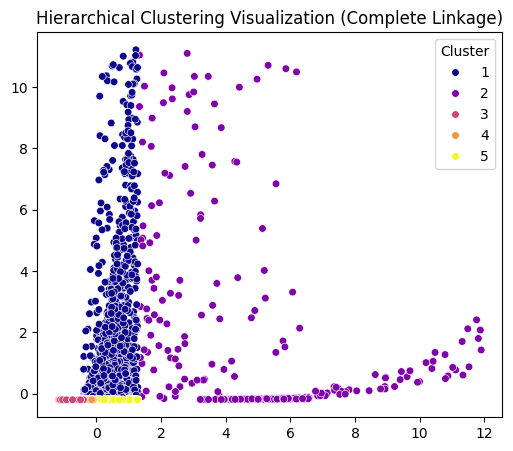

In [ ]:
# Cluster Visualization
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_ward, palette='plasma', s=30)
plt.title("Hierarchical Clustering Visualization (Complete Linkage)")
plt.legend(title='Cluster', loc='best')
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
print("Training DBSCAN Clustering.")

# Model initialization
dbscan = DBSCAN(eps=0.7, min_samples=6)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Some points may be labeled -1
unique_labels = np.unique(labels_dbscan)
print("Unique cluster labels:\n", unique_labels)

# Filter out noise points for evaluation
mask = labels_dbscan != -1
if len(set(labels_dbscan)) > 1 and np.sum(mask) > 0:
    sil_dbscan = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    ch_dbscan = calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask])
    db_dbscan = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
else:
    sil_dbscan = ch_dbscan = db_dbscan = None

print(f"\nSilhouette Score (DBSCAN): {sil_dbscan}")
print(f"Calinski–Harabasz Index (DBSCAN): {ch_dbscan}")
print(f"Davies–Bouldin Index (DBSCAN): {db_dbscan}")


Training DBSCAN Clustering.
Unique cluster labels:
 [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174]

Silhouette Score (DBSCAN): 0.4466095739300534
Calinski–Harabasz Index (DBSCAN): 425.93603394298117
Davies–Bouldin Index (DBSCAN): 0.7580325792458352


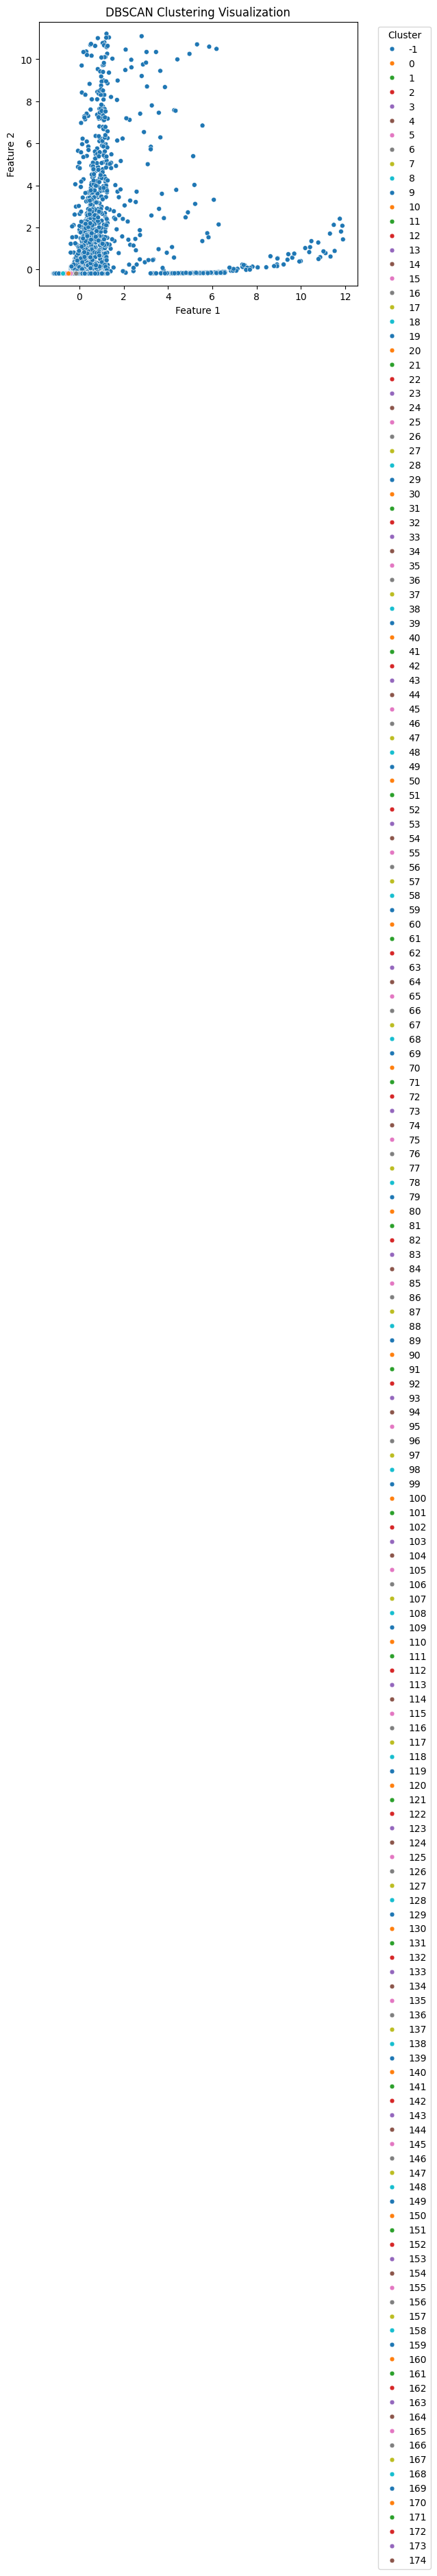

In [ ]:
# Visualization

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_dbscan, palette='tab10', s=25)
plt.title("DBSCAN Clustering Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title='Cluster', loc='best', bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
# Clustering Model Comparison
import pandas as pd

summary_cluster = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [sil_kmeans, sil_ward, sil_dbscan],
    'Calinski–Harabasz Index': [ch_kmeans, ch_ward, ch_dbscan],
    'Davies–Bouldin Index': [db_kmeans, db_ward, db_dbscan]
})

print("\nClustering Model Comparison Summary:")
summary_cluster



Clustering Model Comparison Summary:


,Model,Silhouette Score,Calinski–Harabasz Index,Davies–Bouldin Index
0,K-Means,0.189146,1879.612146,1.857590
1,Hierarchical,0.171380,1918.710546,1.925060
2,DBSCAN,0.446610,425.936034,0.758033


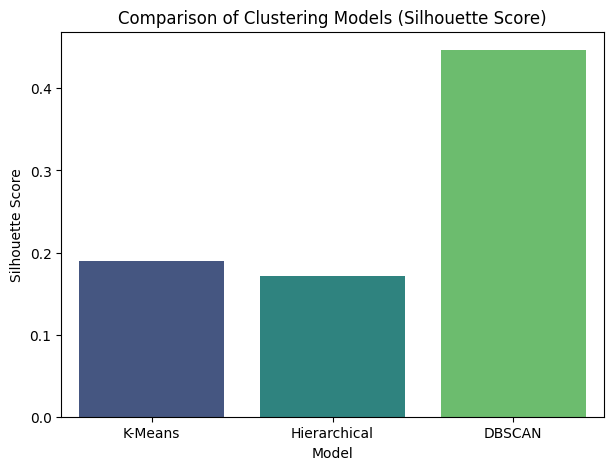

In [ ]:
# Visualization
plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Silhouette Score', hue='Model', data=summary_cluster, palette='viridis', legend=False)
plt.title("Comparison of Clustering Models (Silhouette Score)")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.show()


Both K-Means and Hierarchical clustering were applied to group stars based on their characteristics. The models were evaluated using Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index. Among the two, K-Means performed slightly better, showing higher cluster cohesion and separation, making it more suitable for this dataset.